In [1]:
import pandas as pd
import sys
import numpy as np

In [2]:
import matplotlib.pyplot as plt

## Deterministic

In [3]:
import os

folder_of_interest_list = [
    'results_shipsnet_deterministic_00_SEU',
    'results_shipsnet_deterministic_01_SEU',
    'results_shipsnet_deterministic_02_SEU',
    'results_shipsnet_deterministic_03_SEU',
    ]

df_deterministic = pd.read_csv(r'results_shipsnet_deterministic\results_shipsnet_deterministic_00_SEU\_20250807_170542.csv')
# delete all rows leaving the columns only
# add a column called folder_name
df_deterministic['folder_name'] = ""
df_deterministic = df_deterministic.drop(df_deterministic.index)

for foil in folder_of_interest_list:

#folder_of_interest = 'results_shipsnet_01_SEU'
#folder_of_interest = 'results_GP_shipsnet_newslate_guide_SEU'

#df_deterministic = pd.read_csv(r'results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234102.csv')
# add a column called timestamp, which is the filename without the extension
#df_deterministic['timestamp'] = ""

    search_dir = os.path.join('results_shipsnet_deterministic',
                            foil,
    )

    for file in os.listdir(search_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(search_dir, file)
            print(f"Processing file: {file_path}")
            df = pd.read_csv(file_path)
            df['folder_name'] = foil
            # remove if accuracy_after_seu is nan
            df = df[df['accuracy_after_seu'].notna()]
            print(f"Number of rows after removing NaN in 'accuracy_after_seu': {len(df)}")
            #remove duplicate rows based on the first 10 columns
            print(f"Number of rows before dropping duplicates: {len(df)}")
            df = df.drop_duplicates(subset=df.columns[:10])
            print(f"Number of rows after dropping duplicates: {len(df)}")
            # append the data to the master dataframe
            df_deterministic = pd.concat([df_deterministic, df], ignore_index=True)
    #

# filter accuracy_change to only non nan values
#abs_acc_change_mean = df_deterministic[df_deterministic['accuracy_change'].notna()]['accuracy_change'].abs().mean()
#abs_acc_change_mean\
df_deterministic['abs_acc_diff'] = df_deterministic['accuracy_change'].abs()
df_deterministic['log_mean_abs_difference'] = df_deterministic['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else np.nan)
df_deterministic['diff_per_softmax'] = df_deterministic['abs_acc_diff'] / df_deterministic['softmax_difference']

folder_name_map = {
    'results_shipsnet_deterministic_00_SEU': 'Model 0',
    'results_shipsnet_deterministic_01_SEU': 'Model 1',
    'results_shipsnet_deterministic_02_SEU': 'Model 2',
    'results_shipsnet_deterministic_03_SEU': 'Model 3',
}
df_deterministic['folder_name'] = df_deterministic['folder_name'].map(folder_name_map)

Processing file: results_shipsnet_deterministic\results_shipsnet_deterministic_00_SEU\_20250807_170542.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Number of rows after dropping duplicates: 84
Processing file: results_shipsnet_deterministic\results_shipsnet_deterministic_00_SEU\_20250807_171251.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Number of rows after dropping duplicates: 84
Processing file: results_shipsnet_deterministic\results_shipsnet_deterministic_00_SEU\_20250807_171408.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Number of rows after dropping duplicates: 84
Processing file: results_shipsnet_deterministic\results_shipsnet_deterministic_00_SEU\_20250807_171434.csv
Number of rows after removing NaN in 'accuracy_after_seu': 84
Number of rows before dropping duplicates: 84
Numbe

In [4]:
df_deterministic

,activation_fn,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference,diff_per_softmax
0,relu,0,conv1,weight,0,0.97625,0.97625,0.00000,0.262279,2.236513e-02,NaN,0,Model 0,0.00000,-1.650429,0.000000
1,relu,0,conv1,weight,1,0.97625,0.71625,-0.26000,0.388053,3.805229e+36,NaN,0,Model 0,0.26000,36.580381,0.670011
2,relu,0,conv1,weight,3,0.97625,0.97625,0.00000,0.262237,1.118256e-02,NaN,1,Model 0,0.00000,-1.951459,0.000000
3,relu,0,conv1,weight,6,0.97625,0.97625,0.00000,0.262037,1.677385e-01,NaN,0,Model 0,0.00000,-0.775367,0.000000
4,relu,0,conv1,weight,10,0.97625,0.97625,0.00000,0.262204,1.953125e-03,NaN,1,Model 0,0.00000,-2.709270,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2347,relu,-1,fc1,bias,3,0.97375,0.97375,0.00000,0.263226,3.650101e-02,NaN,1,Model 3,0.00000,-1.437695,0.000000
2348,relu,-1,fc1,bias,6,0.97375,0.97750,0.00375,0.263429,5.475152e-01,NaN,0,Model 3,0.00375,-0.261604,0.014235
2349,relu,-1,fc1,bias,10,0.97375,0.97375,0.00000,0.263208,7.812500e-03,NaN,0,Model 3,0.00000,-2.107210,0.000000
2350,relu,-1,fc1,bias,15,0.97375,0.97375,0.00000,0.263211,2.441406e-04,NaN,1,Model 3,0.00000,-3.612360,0.000000


In [5]:
# make a list of file in the directory

import os

folder_of_interest_list = [
    'results_shipsnet_v02_00_SEU',
    'results_shipsnet_v02_01_SEU',
    'results_shipsnet_v02_02_SEU',
    'results_shipsnet_v02_03_SEU',
    ]

df_bayesian = pd.read_csv(r'results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_013752.csv')
# delete all rows leaving the columns only
# add a column called folder_name
df_bayesian['folder_name'] = ""
df_bayesian = df_bayesian.drop(df_bayesian.index)

for foil in folder_of_interest_list:

#folder_of_interest = 'results_shipsnet_01_SEU'
#folder_of_interest = 'results_GP_shipsnet_newslate_guide_SEU'

#df_bayesian = pd.read_csv(r'results_4_variants\results_GP_shipsnet_newslate_guide_SEU\_20250718_234102.csv')
# add a column called timestamp, which is the filename without the extension
#df_bayesian['timestamp'] = ""

    search_dir = os.path.join('results_shipsnet_new_uniform',
                            foil,
    )

    for file in os.listdir(search_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(search_dir, file)
            print(f"Processing file: {file_path}")
            df = pd.read_csv(file_path)
            df['folder_name'] = foil
            # remove if accuracy_after_seu is nan
            df = df[df['accuracy_after_seu'].notna()]
            print(f"Number of rows after removing NaN in 'accuracy_after_seu': {len(df)}")
            #remove duplicate rows based on the first 10 columns
            print(f"Number of rows before dropping duplicates: {len(df)}")
            df = df.drop_duplicates(subset=df.columns[:10])
            print(f"Number of rows after dropping duplicates: {len(df)}")
            # append the data to the master dataframe
            df_bayesian = pd.concat([df_bayesian, df], ignore_index=True)
    #

# filter accuracy_change to only non nan values
#abs_acc_change_mean = df_bayesian[df_bayesian['accuracy_change'].notna()]['accuracy_change'].abs().mean()
#abs_acc_change_mean\
df_bayesian['abs_acc_diff'] = df_bayesian['accuracy_change'].abs()
df_bayesian['log_mean_abs_difference'] = df_bayesian['mean_abs_difference'].apply(lambda x: np.log10(x) if x > 0 else np.nan)
df_bayesian['diff_per_softmax'] = df_bayesian['abs_acc_diff'] / df_bayesian['softmax_difference']

folder_name_map = {
    'results_shipsnet_v02_00_SEU': 'Model 0',
    'results_shipsnet_v02_01_SEU': 'Model 1',
    'results_shipsnet_v02_02_SEU': 'Model 2',
    'results_shipsnet_v02_03_SEU': 'Model 3',
}
df_bayesian['folder_name'] = df_bayesian['folder_name'].map(folder_name_map)
df_bayesian['remarks'] = df_bayesian['remarks'].fillna('No remarks')  # Fill NaN values in 'remarks' with empty strings

param_type_map = {
    'locs': 'center',
    'lows': 'center',
    'scales': 'spread',
    'widths': 'spread',
}
df_bayesian['param_type_group'] = df_bayesian['param_type'].map(param_type_map)

Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_013752.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 156
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_014138.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 156
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_014145.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 156
Processing file: results_shipsnet_new_uniform\results_shipsnet_v02_00_SEU\_20250806_022604.csv
Number of rows after removing NaN in 'accuracy_after_seu': 156
Number of rows before dropping duplicates: 156
Number of rows after dropping duplicates: 

In [73]:
import numpy as np
import pandas as pd

# ---------- 1) Long → Wide (ID columns + metric groups: DNN | BNN) ----------
def reshape_for_compare(summary_table, id_cols=None):
    """
    summary_table: long-form with columns: id_cols + ['model_type'] + metrics
    id_cols: list of columns to keep on the left (one or more).
    """
    metrics = ["abs_acc_diff", "softmax_difference", "metrics_rms"]
    df = summary_table.copy()

    # default ID columns
    if id_cols is None:
        candidates = [c for c in df.columns if c not in metrics + ["model_type"]]
        id_cols = candidates or ["folder_name"]

    # Pivot so model_type becomes the 2 subcolumns per metric
    wide = (
        df.pivot(index=id_cols, columns="model_type", values=metrics)
          .reindex(columns=pd.MultiIndex.from_product([metrics, ["DNN", "BNN"]]))
          .reset_index()
    )
    return wide


# ---------- 2) LaTeX builder with options ----------
def create_neat_latex(summary_table, comment="",
                      highlight="pair",   # 'pair' | 'col' | 'off'
                      ascending=True,
                      id_cols=None):
    """
    - If `summary_table` is long (has 'model_type' and not MultiIndex columns), it is reshaped.
    - highlight:
        'pair' -> within-row compare DNN vs BNN, bold the better.
        'col'  -> across-rows compare within each column, bold the best in that column.
        'off'  -> no bolding.
    """
    metrics = ["abs_acc_diff", "softmax_difference", "metrics_rms"]

    # If input is long, reshape it first
    if ("model_type" in summary_table.columns) and not isinstance(summary_table.columns, pd.MultiIndex):
        df = reshape_for_compare(summary_table, id_cols=id_cols)
    else:
        df = summary_table.copy()
        if id_cols is None:
            if isinstance(df.columns, pd.MultiIndex):
                id_cols = [c[1] for c in df.columns if c[0] == ""]
            else:
                id_cols = [df.columns[0]]

    # ---------- helper for number formatting ----------
    def fmt_val(v, is_best):
        val_str = f"{float(v):.4f}".lstrip("0")  # removes leading 0
        return r"\B{%d}{%s}" % (1 if is_best else 0, val_str)

    def fmt_val_col(v, best):
        val_str = f"{float(v):.4f}".lstrip("0")
        return r"\B{%d}{%s}" % (1 if np.isclose(v, best) else 0, val_str)

    # ---------- highlighting ----------
    if highlight == "pair":
        for m in metrics:
            if (m, "DNN") in df.columns and (m, "BNN") in df.columns:
                det = df[(m, "DNN")].astype(float)
                bay = df[(m, "BNN")].astype(float)
                target = np.minimum(det, bay) if ascending else np.maximum(det, bay)

                df[(m, "DNN")] = [fmt_val(v, np.isclose(v, t)) for v, t in zip(det, target)]
                df[(m, "BNN")] = [fmt_val(v, np.isclose(v, t)) for v, t in zip(bay, target)]

    elif highlight == "col":
        for col in df.columns:
            if isinstance(col, tuple) and col[0] in metrics:
                vals = df[col].astype(float)
                best = vals.min() if ascending else vals.max()
                df[col] = [fmt_val_col(v, best) for v in vals]

    # 'off' → do nothing

    # ---------- ensure 2-level header ----------
    if not isinstance(df.columns, pd.MultiIndex):
        df.columns = [("", c) for c in df.columns]

    df.columns = pd.MultiIndex.from_tuples(
        [c if isinstance(c, tuple) else ("", c) for c in df.columns],
        names=["metric", ""]
    )

    # ---------- column format with vertical bars between metric groups ----------
    n_id = sum(1 for c in df.columns if c[0] == "")
    colfmt = "l" * n_id + "|" + "|".join(["rr"] * len(metrics))

    latex_core = df.to_latex(
        index=False, escape=False,
        multicolumn=True, multirow=False,
        column_format=colfmt
    )

    # Center the group headers
    latex_core = latex_core.replace(r"\multicolumn{2}{r}{", r"\multicolumn{2}{c}{")

    # Add vertical bars after the first two groups in header
    parts = latex_core.split(r"\multicolumn{2}{c}{")
    if len(parts) >= len(metrics) + 1:
        latex_core = parts[0]
        for i, block in enumerate(parts[1:], start=1):
            if i < len(metrics):
                latex_core += r"\multicolumn{2}{c|}{" + block
            else:
                latex_core += r"\multicolumn{2}{c}{" + block

    # ---------- final assembly ----------
    final = "\n".join([
        "%"+comment,
        r"\begin{table}[H]",
        r"\centering",
        latex_core,
        r"\caption{...}",
        r"\label{table:...}",
        r"\end{table}",
    ])

    final = final.replace("_", r"\_")
    return final


In [6]:
df_deterministic.head()

,activation_fn,location_index,location_layer,location_module,bit_index,initial_accuracy,accuracy_after_seu,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference,diff_per_softmax
0,relu,0,conv1,weight,0,0.97625,0.97625,0.00,0.262279,2.236513e-02,NaN,0,Model 0,0.00,-1.650429,0.000000
1,relu,0,conv1,weight,1,0.97625,0.71625,-0.26,0.388053,3.805229e+36,NaN,0,Model 0,0.26,36.580381,0.670011
2,relu,0,conv1,weight,3,0.97625,0.97625,0.00,0.262237,1.118256e-02,NaN,1,Model 0,0.00,-1.951459,0.000000
3,relu,0,conv1,weight,6,0.97625,0.97625,0.00,0.262037,1.677385e-01,NaN,0,Model 0,0.00,-0.775367,0.000000
4,relu,0,conv1,weight,10,0.97625,0.97625,0.00,0.262204,1.953125e-03,NaN,1,Model 0,0.00,-2.709270,0.000000


In [7]:
df_bayesian.head()

,activation_fn,prior,best_accuracy,prior_mu,prior_b,param_type,location_index,location_layer,location_module,bit_index,...,accuracy_change,softmax_difference,mean_abs_difference,remarks,original_bit_condition,folder_name,abs_acc_diff,log_mean_abs_difference,diff_per_softmax,param_type_group
0,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,0,...,0.00500,0.060008,5.618616e-01,No remarks,1,Model 0,0.00500,-0.250371,0.083322,center
1,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,1,...,-0.16250,0.927500,9.559580e+37,AutoUniform width adjusted;,0,Model 0,0.16250,37.980439,0.175202,center
2,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,1,...,-0.16375,0.960000,2.162142e+38,No remarks,0,Model 0,0.16375,38.334884,0.170573,spread
3,relu,uniform,0.868437,0.0,1.0,lows,0,conv1,weight,3,...,-0.00125,0.044789,2.809308e-01,No remarks,1,Model 0,0.00125,-0.551401,0.027908,center
4,relu,uniform,0.868437,0.0,1.0,widths,0,conv1,weight,3,...,0.00125,0.051512,6.353964e-01,AutoUniform width adjusted;,1,Model 0,0.00125,-0.196955,0.024266,spread


In [8]:
# compare the two dataframes columns
common_columns = set(df_deterministic.columns).intersection(set(df_bayesian.columns))
different_columns = set(df_deterministic.columns).symmetric_difference(set(df_bayesian.columns))

In [70]:
# combine the two dataframes
# add a new column 'source' to differentiate between the two dataframes
df_bayesian['model_type'] = 'BNN'
df_deterministic['model_type'] = 'DNN'
df_combined = pd.concat([df_bayesian, df_deterministic], ignore_index=True)
df_combined["param_type"] = df_combined['param_type'].fillna('No param type')  # Fill NaN values in 'param_type' with 'No param type'
df_combined["param_type_group"] = df_combined['param_type_group'].fillna('No param type group')  # Fill NaN values in 'param_type' with 'No param type'
df_combined["prior"] = df_combined['prior'].fillna('No prior')  # Fill NaN values in 'prior' with 'No prior'
df_combined["remarks"] = df_combined['remarks'].fillna('No remarks')

In [10]:
df_combined['param_type_group'].unique()

array(['center', 'spread', 'No param type group'], dtype=object)

In [11]:
df_combined.groupby(['activation_fn', 'prior', 'folder_name']).size().reset_index(name='count')

,activation_fn,prior,folder_name,count
0,actRWG,No prior,Model 0,84
1,actRWG,No prior,Model 1,84
2,actRWG,No prior,Model 2,84
3,actRWG,No prior,Model 3,84
4,actRWG,gaussian,Model 0,156
...,...,...,...,...
107,tanh,laplace,Model 3,156
108,tanh,uniform,Model 0,156
109,tanh,uniform,Model 1,156
110,tanh,uniform,Model 2,156


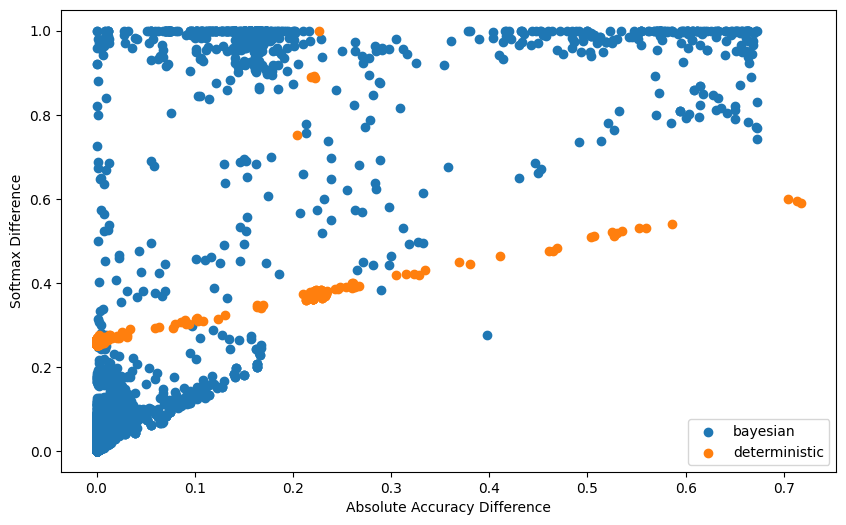

In [12]:
plt.figure(figsize=(10, 6))
for modeltype in df_combined['model_type'].unique():
    subset = df_combined[df_combined['model_type'] == modeltype]
    plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=modeltype)
#plt.scatter(df_master['abs_acc_diff'], df_master['softmax_difference'])
plt.xlabel('Absolute Accuracy Difference')
plt.ylabel('Softmax Difference')
#plt.title('Absolute Accuracy Difference vs Softmax Difference')
plt.legend()

In [13]:
df_combined['remarks'].unique()

array(['No remarks', 'AutoUniform width adjusted; ',
       'SEU went to NaN or Inf clipping to finite range; '], dtype=object)

In [14]:
df_combined_noinf = df_combined[df_combined['remarks']!='SEU went to NaN or Inf clipping to finite range; ']

In [15]:
df_summary_0 = df_combined.groupby(['model_type'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_0['diff_per_softmax'] = df_summary_0['abs_acc_diff'] / df_summary_0['softmax_difference']
df_summary_0

,model_type,abs_acc_diff,softmax_difference,diff_per_softmax
0,bayesian,0.024377,0.107398,0.226980
1,deterministic,0.014907,0.269554,0.055302


In [16]:
df_summary_0 = df_combined_noinf.groupby(['model_type'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_0['diff_per_softmax'] = df_summary_0['abs_acc_diff'] / df_summary_0['softmax_difference']
df_summary_0

,model_type,abs_acc_diff,softmax_difference,diff_per_softmax
0,bayesian,0.021836,0.099915,0.218544
1,deterministic,0.014907,0.269554,0.055302


In [17]:
df_summary_0 = df_combined.groupby(['model_type','param_type_group'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_0['diff_per_softmax'] = df_summary_0['abs_acc_diff'] / df_summary_0['softmax_difference']
df_summary_0

,model_type,param_type_group,abs_acc_diff,softmax_difference,diff_per_softmax
0,bayesian,center,0.020048,0.089040,0.225156
1,bayesian,spread,0.029428,0.128815,0.228451
2,deterministic,No param type group,0.014907,0.269554,0.055302


In [74]:
df_summary_0 = df_combined.groupby(['model_type','folder_name'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_0['diff_per_softmax'] = df_summary_0['abs_acc_diff'] / df_summary_0['softmax_difference']
df_summary_0['metrics_rms'] = np.sqrt((df_summary_0['abs_acc_diff']**2 + df_summary_0['softmax_difference']**2)/2)
df_summary_0

,model_type,folder_name,abs_acc_diff,softmax_difference,metrics_rms
0,BNN,Model 0,0.024265,0.110569,0.080045
1,BNN,Model 1,0.025410,0.110913,0.080459
2,BNN,Model 2,0.022094,0.094354,0.068523
3,BNN,Model 3,0.025739,0.113756,0.082471
4,DNN,Model 0,0.014532,0.269426,0.190790
5,DNN,Model 1,0.014158,0.269877,0.191094
6,DNN,Model 2,0.015721,0.270202,0.191385
7,DNN,Model 3,0.015217,0.268711,0.190312


In [75]:
wide_df = reshape_for_compare(df_summary_0)  # keeps only folder_name on the left
tex = create_neat_latex(df_summary_0,
                        comment="bayesian vs deterministic per metric",
                        highlight="col",     # 'pair' | 'col' | 'off'
                        ascending=True,
                        id_cols=["folder_name"])
print(tex)

%bayesian vs deterministic per metric
\begin{table}[H]
\centering
\begin{tabular}{|rr|rr|rr}
\toprule
folder\_name & \multicolumn{2}{c|}{abs\_acc\_diff} & \multicolumn{2}{c|}{softmax\_difference} & \multicolumn{2}{c}{metrics\_rms} \\
 & DNN & BNN & DNN & BNN & DNN & BNN \\
\midrule
Model 0 & \B{0}{.0145} & \B{0}{.0243} & \B{0}{.2694} & \B{0}{.1106} & \B{0}{.1908} & \B{0}{.0800} \\
Model 1 & \B{1}{.0142} & \B{0}{.0254} & \B{0}{.2699} & \B{0}{.1109} & \B{0}{.1911} & \B{0}{.0805} \\
Model 2 & \B{0}{.0157} & \B{1}{.0221} & \B{0}{.2702} & \B{1}{.0944} & \B{0}{.1914} & \B{1}{.0685} \\
Model 3 & \B{0}{.0152} & \B{0}{.0257} & \B{1}{.2687} & \B{0}{.1138} & \B{1}{.1903} & \B{0}{.0825} \\
\bottomrule
\end{tabular}

\caption{...}
\label{table:...}
\end{table}


In [76]:
# I want the model_type to be like a pivot under the column
df_summary_0 = df_combined.groupby(['model_type','folder_name','param_type_group'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_0['diff_per_softmax'] = df_summary_0['abs_acc_diff'] / df_summary_0['softmax_difference']
df_summary_0

,model_type,folder_name,param_type_group,abs_acc_diff,softmax_difference,diff_per_softmax
0,BNN,Model 0,center,0.020386,0.092088,0.221377
1,BNN,Model 0,spread,0.028791,0.132130,0.217901
2,BNN,Model 1,center,0.021342,0.093065,0.229326
3,BNN,Model 1,spread,0.030155,0.131736,0.228908
4,BNN,Model 2,center,0.016677,0.075541,0.220772
5,BNN,Model 2,spread,0.028414,0.116302,0.244316
6,BNN,Model 3,center,0.021786,0.095468,0.228207
7,BNN,Model 3,spread,0.030351,0.135093,0.224665
8,DNN,Model 0,No param type group,0.014532,0.269426,0.053938
9,DNN,Model 1,No param type group,0.014158,0.269877,0.052461


In [77]:
# bitflip for index 1 in the deterministic model is more harsh in accuracy difference

df_summary_0 = df_combined.groupby(['model_type','bit_index'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
df_summary_0['diff_per_softmax'] = df_summary_0['abs_acc_diff'] / df_summary_0['softmax_difference']
df_summary_0

,model_type,bit_index,abs_acc_diff,softmax_difference,diff_per_softmax
0,BNN,0,0.007458,0.053293,0.139940
1,BNN,1,0.120603,0.408042,0.295566
2,BNN,3,0.007038,0.052738,0.133453
3,BNN,6,0.006987,0.052928,0.132013
4,BNN,10,0.006729,0.052472,0.128246
5,BNN,15,0.006673,0.052493,0.127119
6,BNN,21,0.006692,0.052766,0.126825
7,DNN,0,0.000465,0.261319,0.001780
8,DNN,1,0.102295,0.319264,0.320410
9,DNN,3,0.000223,0.261192,0.000855


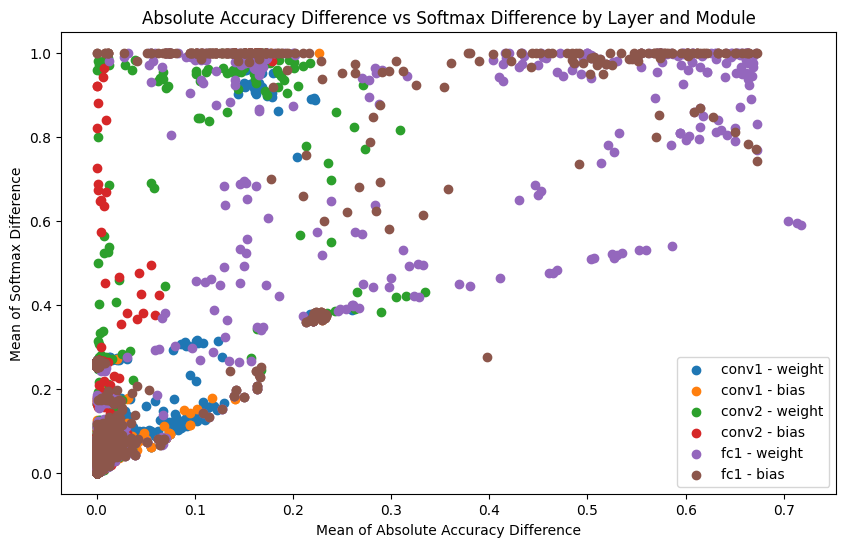

In [78]:
plt.figure(figsize=(10, 6))
for layer in df_combined['location_layer'].unique():
    for module in df_combined['location_module'].unique():
        subset = df_combined[(df_combined['location_layer'] == layer) & (df_combined['location_module'] == module)]
        plt.scatter(subset['abs_acc_diff'], subset['softmax_difference'], label=f'{layer} - {module}')
plt.xlabel('Mean of Absolute Accuracy Difference')
plt.ylabel('Mean of Softmax Difference')
plt.title('Absolute Accuracy Difference vs Softmax Difference by Layer and Module')
plt.legend()

In [79]:
df_summary_3 = df_combined.groupby(['activation_fn','model_type'])[["abs_acc_diff","softmax_difference"]].mean().reset_index()
#df_summary_3['diff_per_softmax'] = df_summary_3['abs_acc_diff'] / df_summary_3['softmax_difference']
df_summary_3['metrics_rms'] = np.sqrt((df_summary_3['abs_acc_diff']**2 + df_summary_3['softmax_difference']**2)/2)
df_summary_3

,activation_fn,model_type,abs_acc_diff,softmax_difference,metrics_rms
0,actRWG,BNN,0.016810,0.095782,0.068763
1,actRWG,DNN,0.007779,0.265099,0.187534
2,actWG,BNN,0.021318,0.096411,0.069820
3,actWG,DNN,0.017775,0.271577,0.192445
4,relu,BNN,0.037859,0.162583,0.118039
5,relu,DNN,0.023423,0.283511,0.201155
6,relu6,BNN,0.024757,0.101221,0.073684
7,relu6,DNN,0.011369,0.265334,0.187791
8,sigmoid,BNN,0.019042,0.079966,0.058126
9,sigmoid,DNN,0.013624,0.259768,0.183936


In [80]:
wide_df = reshape_for_compare(df_summary_3)  # keeps only folder_name on the left
tex = create_neat_latex(df_summary_3,
                        comment="bayesian vs deterministic per metric",
                        highlight="col",     # 'pair' | 'col' | 'off'
                        ascending=True,
                        id_cols=["activation_fn"])
print(tex)

%bayesian vs deterministic per metric
\begin{table}[H]
\centering
\begin{tabular}{|rr|rr|rr}
\toprule
activation\_fn & \multicolumn{2}{c|}{abs\_acc\_diff} & \multicolumn{2}{c|}{softmax\_difference} & \multicolumn{2}{c}{metrics\_rms} \\
 & DNN & BNN & DNN & BNN & DNN & BNN \\
\midrule
actRWG & \B{1}{.0078} & \B{1}{.0168} & \B{0}{.2651} & \B{0}{.0958} & \B{0}{.1875} & \B{0}{.0688} \\
actWG & \B{0}{.0178} & \B{0}{.0213} & \B{0}{.2716} & \B{0}{.0964} & \B{0}{.1924} & \B{0}{.0698} \\
relu & \B{0}{.0234} & \B{0}{.0379} & \B{0}{.2835} & \B{0}{.1626} & \B{0}{.2012} & \B{0}{.1180} \\
relu6 & \B{0}{.0114} & \B{0}{.0248} & \B{0}{.2653} & \B{0}{.1012} & \B{0}{.1878} & \B{0}{.0737} \\
sigmoid & \B{0}{.0136} & \B{0}{.0190} & \B{1}{.2598} & \B{1}{.0800} & \B{1}{.1839} & \B{1}{.0581} \\
sin & \B{0}{.0141} & \B{0}{.0294} & \B{0}{.2702} & \B{0}{.1056} & \B{0}{.1913} & \B{0}{.0775} \\
tanh & \B{0}{.0163} & \B{0}{.0214} & \B{0}{.2714} & \B{0}{.1102} & \B{0}{.1923} & \B{0}{.0794} \\
\bottomrule
\end{tabula